# UNIVERSIDAD AUTONOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computacion
## Carrera: Ingenieria en Computacion Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** JGuillermo González Lara (237864)
**Semestre:** Enero-Junio del 2026

---

# Practica No. 36 - Descomposicion de Series de Tiempo y Regresion Lineal (Python)

En esta practica se implementa la descomposicion de los componentes (tendencia, ciclicidad, estacionalidad y movimiento aleatorio) y la regresion lineal sobre las series de tiempo de la Practica 32.

Modelo aditivo: $y_t = T_t + C_t + S_t + R_t$

## Paso 1: Instalacion e importacion de librerias

In [3]:
# Instalacion de dependencias necesarias
!pip install pandas numpy matplotlib statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")
print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 2: Cargar series de la Practica 32

Se usa `get_rdataset` para descargar los datasets de la libreria `datasets` de R. Esto requiere conexion a internet la primera vez.

In [4]:
def load_r_ts(name, start, freq, fallback=None):
    try:
        ds = sm.datasets.get_rdataset(name, package="datasets").data
        if "value" in ds.columns:
            values = ds["value"]
        else:
            values = ds.iloc[:, 0]
        idx = pd.date_range(start=start, periods=len(values), freq=freq)
        series = pd.Series(values.to_numpy(dtype="float64"), index=idx, name=name)
        if series.isna().any():
            series = series.interpolate(limit_direction="both")
        return series
    except Exception:
        if fallback == "co2":
            data = sm.datasets.co2.load_pandas().data
            series = data["co2"].copy()
            series = series.interpolate(limit_direction="both")
            series = series.resample("MS").mean().dropna()
            series.name = name
            return series
        if fallback == "sunspots":
            data = sm.datasets.sunspots.load_pandas().data
            years = pd.to_datetime(data["YEAR"].astype(int), format="%Y")
            series = pd.Series(data["SUNACTIVITY"].to_numpy(dtype="float64"), index=years, name=name)
            return series
        raise

series_config = {
    "AirPassengers": {"start": "1949-01-01", "freq": "MS", "period": 12},
    "nottem": {"start": "1920-01-01", "freq": "MS", "period": 12},
    "sunspot.year": {"start": "1700-01-01", "freq": "YS", "period": 11, "fallback": "sunspots"},
    "UKgas": {"start": "1960-01-01", "freq": "QS", "period": 4},
    "co2": {"start": "1959-01-01", "freq": "MS", "period": 12, "fallback": "co2"}
}

series_data = {}
for name, cfg in series_config.items():
    series = load_r_ts(name, cfg["start"], cfg["freq"], cfg.get("fallback"))
    series_data[name] = series
    print(f"{name}: {series.index.min().date()} -> {series.index.max().date()} | n={len(series)}")

display(series_data["AirPassengers"].head())

AirPassengers: 1949-01-01 -> 1960-12-01 | n=144
nottem: 1920-01-01 -> 1939-12-01 | n=240
sunspot.year: 1700-01-01 -> 1988-01-01 | n=289
UKgas: 1960-01-01 -> 1986-10-01 | n=108
co2: 1958-03-01 -> 2001-12-01 | n=526


1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
Freq: MS, Name: AirPassengers, dtype: float64

## Paso 3: Funciones para descomposicion y regresion lineal

In [5]:
def decompose_series(series, period):
    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    components = pd.DataFrame({
        "observed": series,
        "trend": result.trend,
        "seasonal": result.seasonal,
        "resid": result.resid
    })
    deseasonal = components["observed"] - components["seasonal"]
    cycle_raw = deseasonal - components["trend"]
    cycle_window = max(3, period // 2)
    cycle = cycle_raw.rolling(window=cycle_window, center=True, min_periods=max(2, cycle_window // 2)).mean()
    random = cycle_raw - cycle
    components["cycle"] = cycle
    components["random"] = random
    return components

def linear_regression(series):
    t = np.arange(len(series))
    y = series.values
    m, b = np.polyfit(t, y, 1)
    y_hat = m * t + b
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return m, b, r2, y_hat

def plot_components(components, title):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
    axes[0].plot(components.index, components["observed"], color="black", linewidth=1.2)
    axes[0].set_title(f"Serie observada - {title}")

    axes[1].plot(components.index, components["trend"], color="dodgerblue", linewidth=2)
    axes[1].set_title("Tendencia (T)")

    axes[2].plot(components.index, components["cycle"], color="darkorange", linewidth=1.6)
    axes[2].set_title("Ciclicidad (C)")

    axes[3].plot(components.index, components["seasonal"], color="seagreen", linewidth=1.4)
    axes[3].set_title("Estacionalidad (S)")

    axes[4].plot(components.index, components["random"], color="gray", linewidth=1.2)
    axes[4].set_title("Movimiento aleatorio (R)")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_regression(series, y_hat, title, m, b, r2):
    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values, label="Serie", color="steelblue", linewidth=1.2)
    plt.plot(series.index, y_hat, label="Regresion lineal", color="tomato", linewidth=2)
    plt.title(f"{title}: y = {m:.4f} t + {b:.2f} | R^2 = {r2:.3f}")
    plt.xlabel("Fecha")
    plt.ylabel("Valor")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Paso 4: Descomposicion y regresion para cada serie

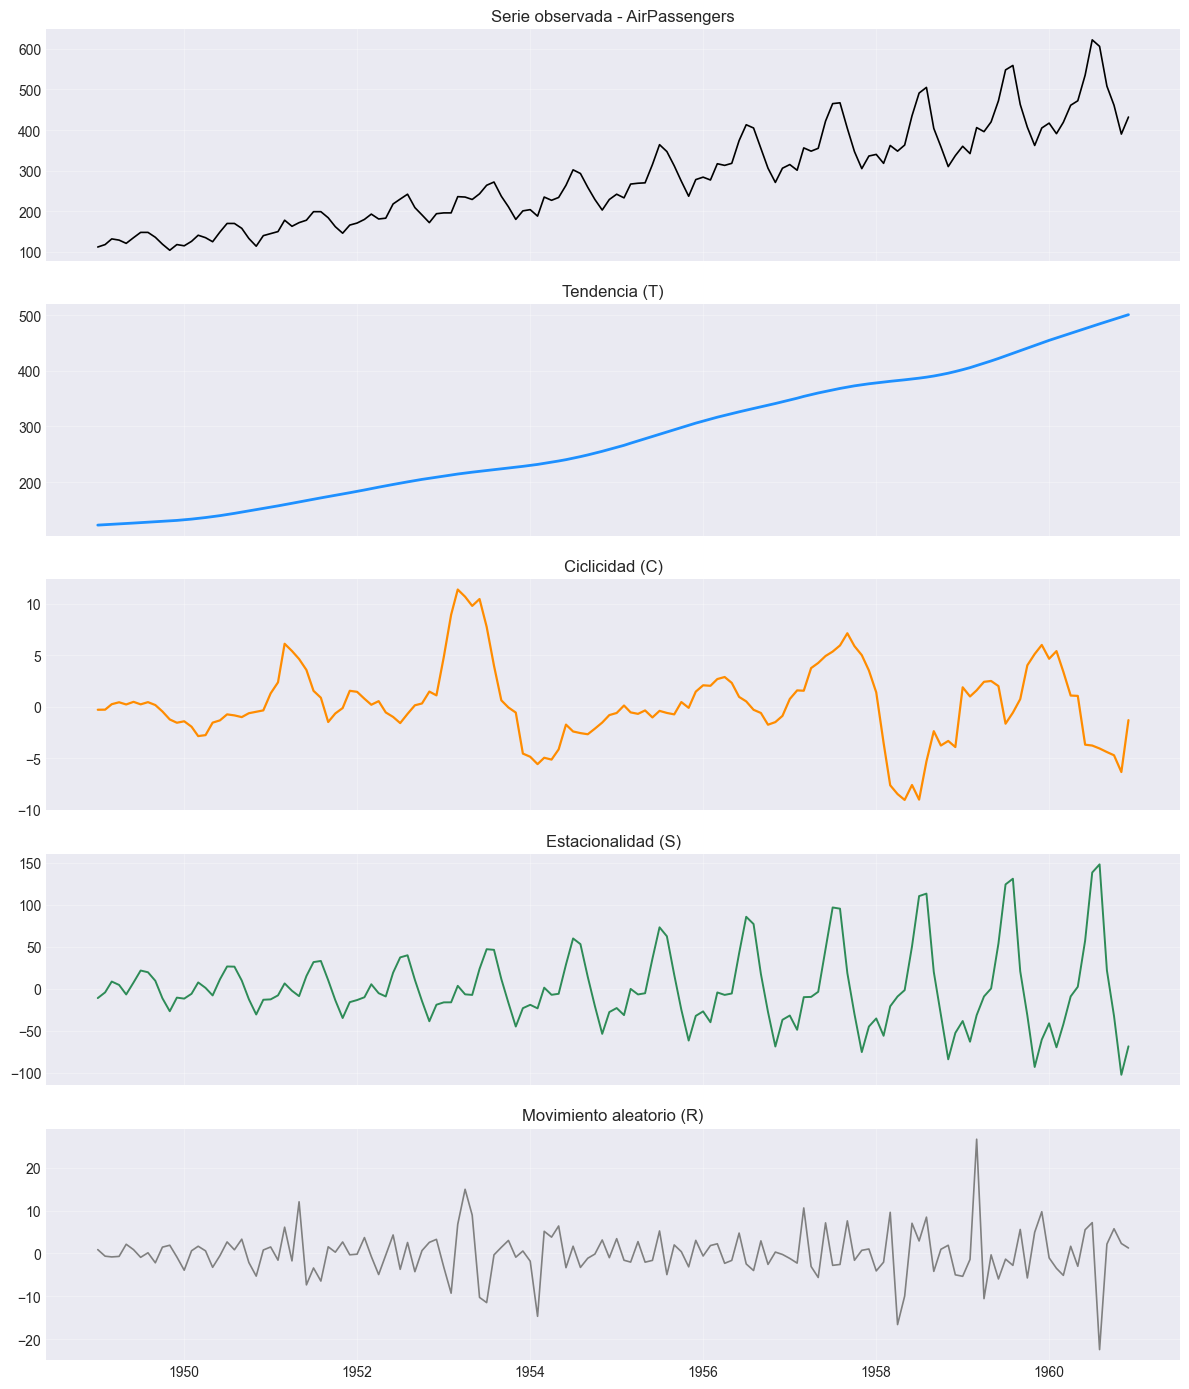

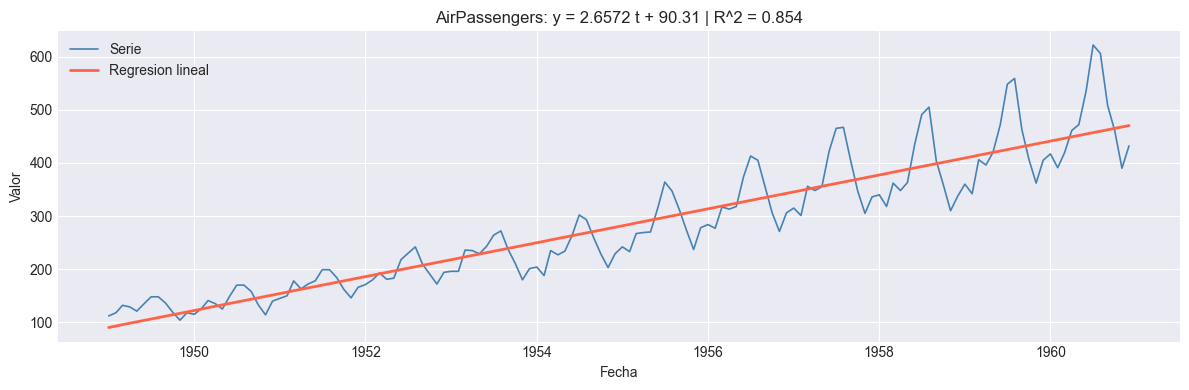

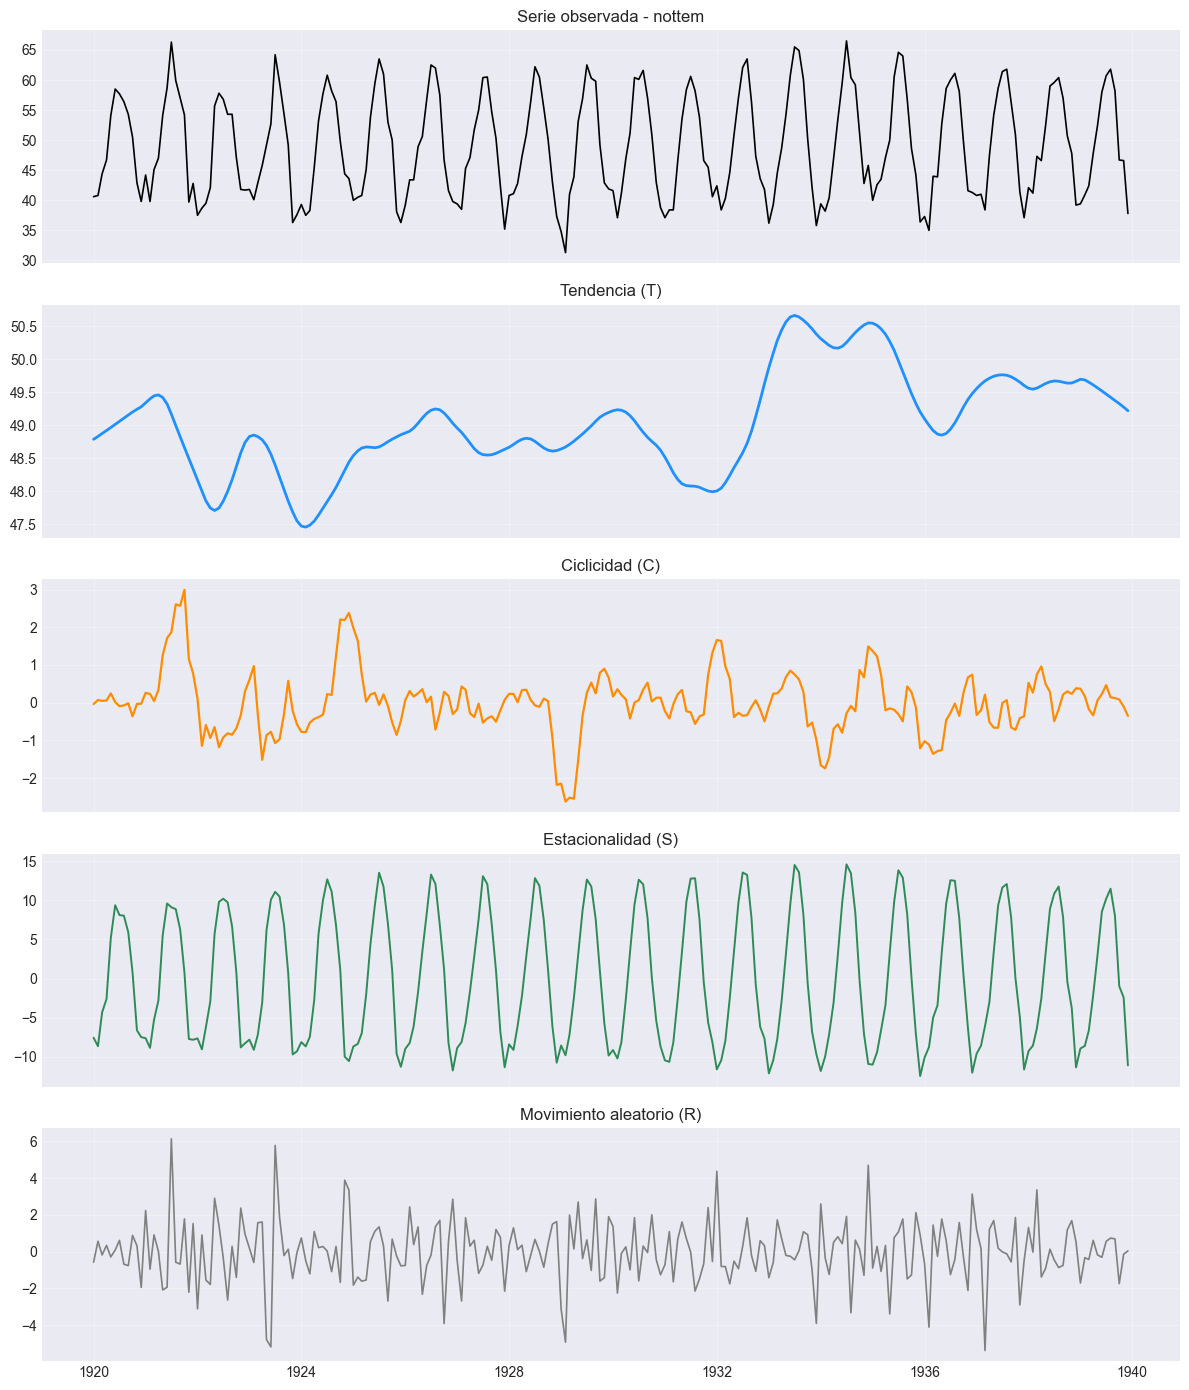

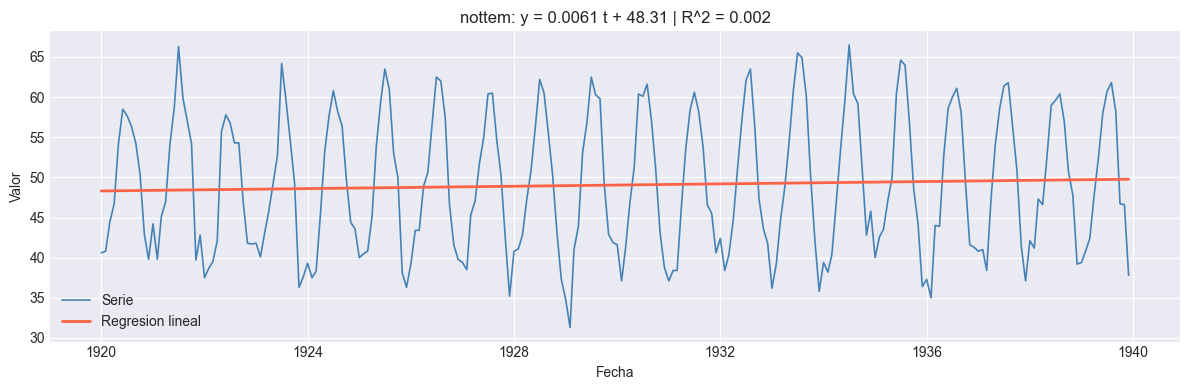

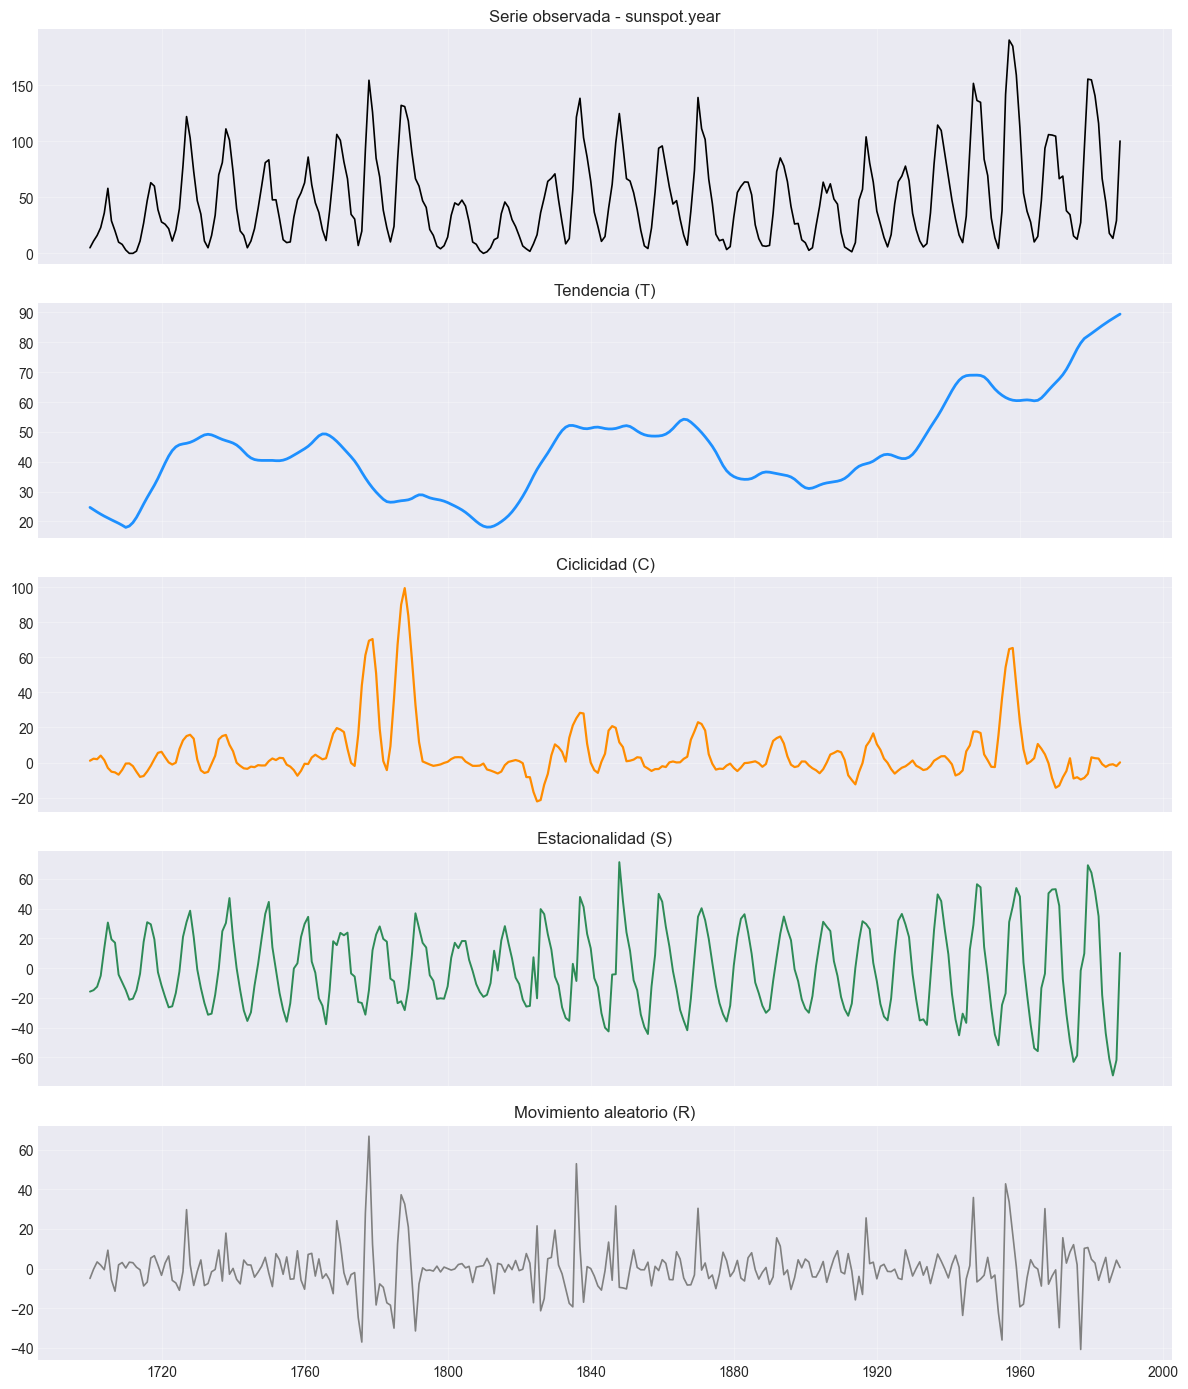

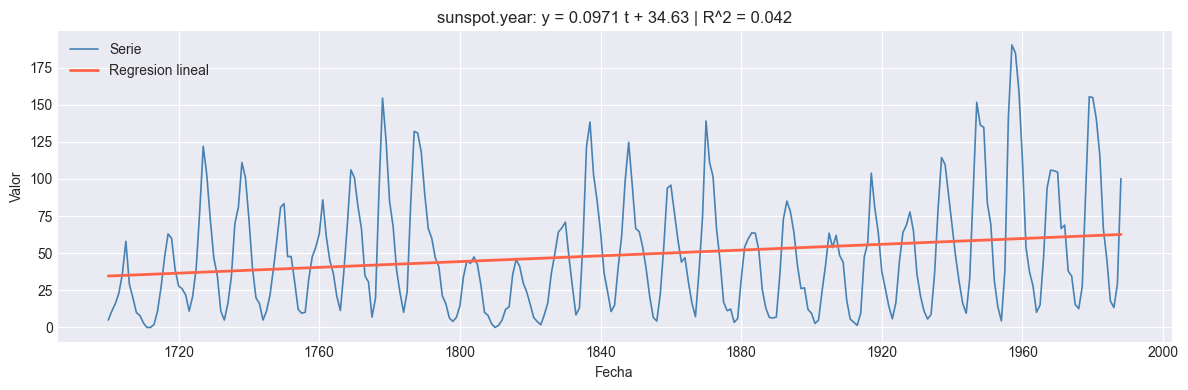

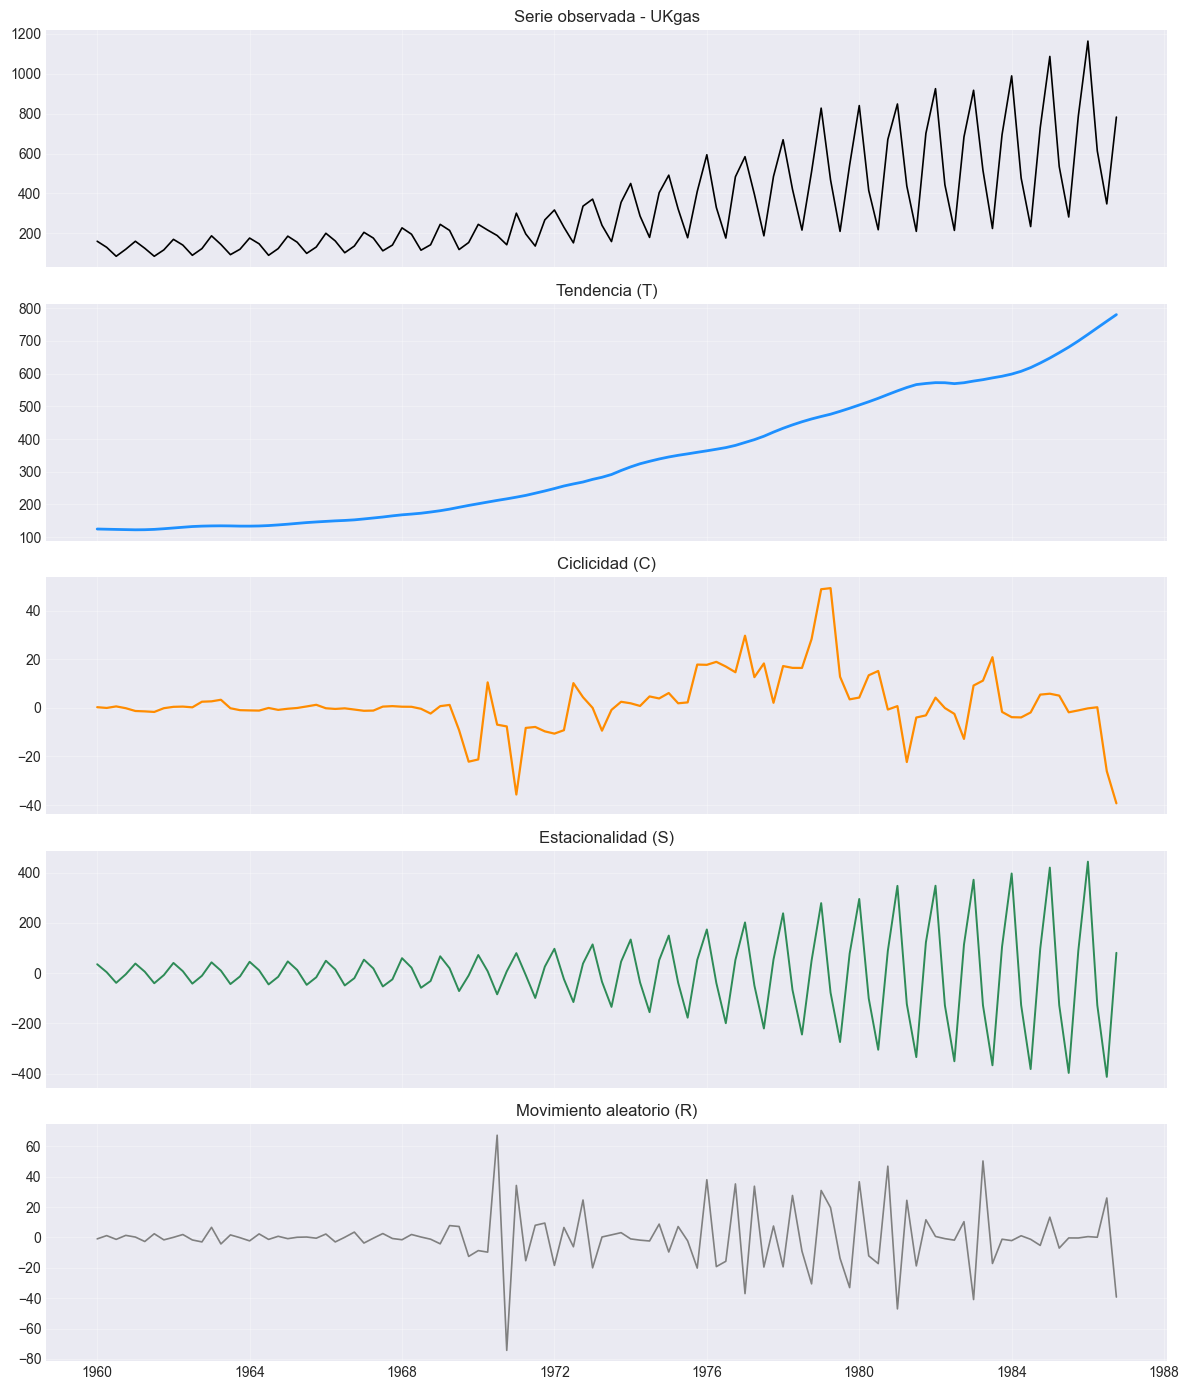

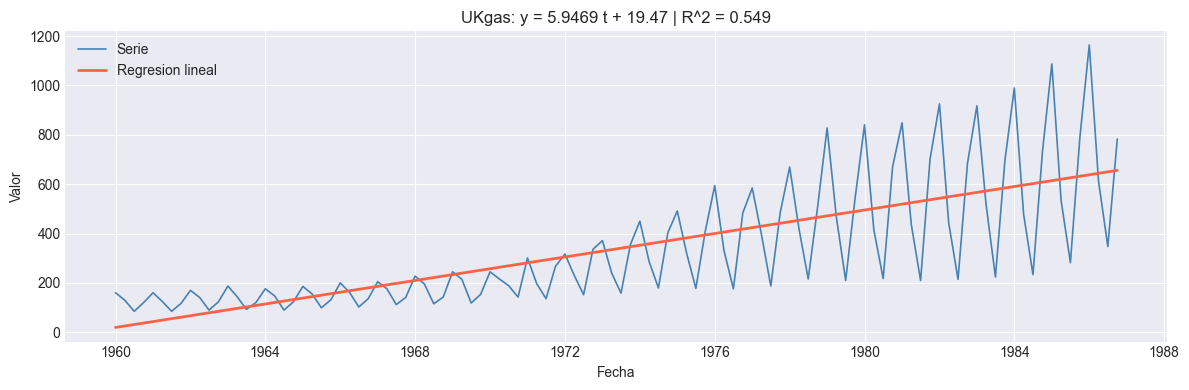

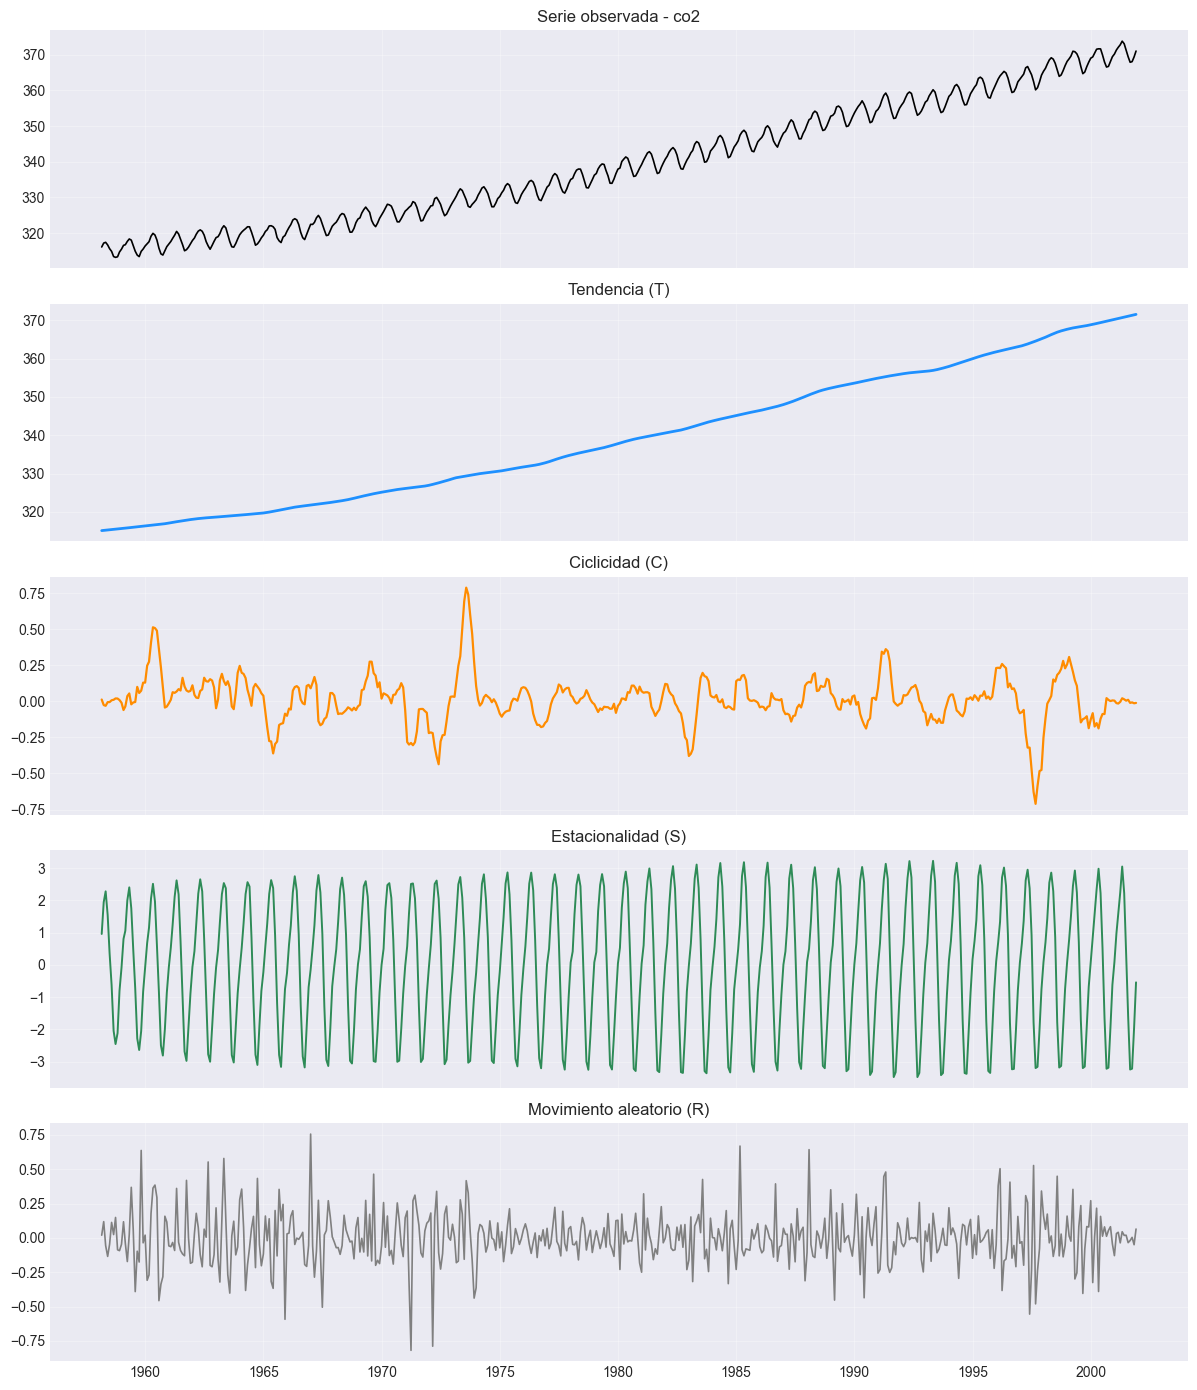

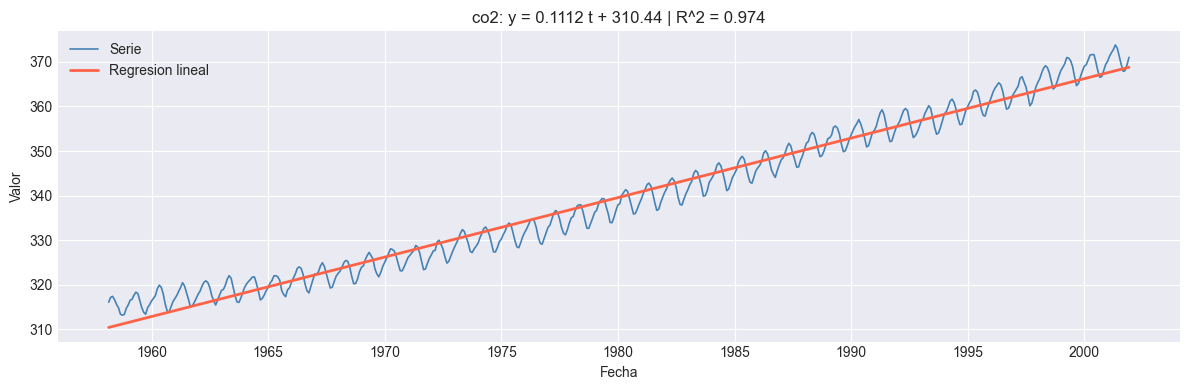

In [6]:
results = []
components_dict = {}

for name, cfg in series_config.items():
    series = series_data[name]
    components = decompose_series(series, cfg["period"])
    components_dict[name] = components

    plot_components(components, name)
    m, b, r2, y_hat = linear_regression(series)
    plot_regression(series, y_hat, name, m, b, r2)

    results.append({
        "Serie": name,
        "Pendiente": m,
        "Intercepto": b,
        "R2": r2
    })

## Paso 5: Resumen de la regresion lineal

In [7]:
df_reg = pd.DataFrame(results).set_index("Serie")
display(df_reg.round(4))

,Pendiente,Intercepto,R2
Serie,,,
AirPassengers,2.6572,90.3100,0.8536
nottem,0.0061,48.3081,0.0025
sunspot.year,0.0971,34.6325,0.0423
UKgas,5.9469,19.4688,0.5492
co2,0.1112,310.4359,0.9743


---
# Conclusiones

- La descomposicion STL separa tendencia y estacionalidad en series mensuales y trimestrales.
- La ciclicidad se observa al suavizar las desviaciones respecto a la tendencia y sin estacionalidad.
- El movimiento aleatorio representa el ruido no explicado por los otros componentes.
- La regresion lineal resume la tendencia global de cada serie y permite comparar pendientes.

## Referencias
1. R datasets package - AirPassengers, nottem, sunspot.year, UKgas, co2
2. Statsmodels Documentation - get_rdataset y STL
3. Hyndman, R. J., & Athanasopoulos, G. (2018). Forecasting: principles and practice.